In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from tensorflow.python.distribute.single_loss_example import single_loss_example
from torch.distributed.fsdp.wrap import lambda_auto_wrap_policy

from epiuc.uncertainty.classification import LeNet_MNIST
from epiuc.uncertainty.wrapper import Ensemble_Classifier
from property_procedures.utils import ensemble_probs, total_uncertainty_ensemble, epistemic_uncertainty_ensemble, \
    aleatoric_uncertainty_ensemble

In [2]:
from config import DATALOADER_CONFIGS, BACKEND


def load_mnist(vali_size=0.1, generator=None, loading_configs=DATALOADER_CONFIGS, ROOT_PATH="data"):
    """
    Load MNIST dataset.
    See `load_image_data` for more details on the arguments.
    :return: MNIST trainloader, valloader, testloader
    """

    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize(mean=[0.1307], std=[0.3081])]
    )

    trainset = torchvision.datasets.MNIST(
        root=ROOT_PATH, train=True, download=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, **loading_configs
    )

    testset = torchvision.datasets.MNIST(
        root=ROOT_PATH, train=False, download=True, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=loading_configs["batch_size"],
        shuffle=False,
        num_workers=loading_configs["num_workers"],
        pin_memory=loading_configs["pin_memory"]
    )

    return trainloader, testloader

In [3]:
trainloader, testloader = load_mnist()

In [4]:
lenet_model = LeNet_MNIST(drop_prob=0.5, in_channels=1, image_width=28, image_heigth=28)
ensemble_lenet = Ensemble_Classifier(
    base_model=lenet_model,
    n_models=5,
    random_state=42
)
ensemble_lenet.load("../models/Ensemble_MNIST/")
ensemble_lenet.compile(backend=BACKEND)
ensemble_lenet.to(device=torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"))

Ensemble_Classifier()

# Train Ensemble of LeNet models

In [5]:
iter_test = iter(testloader)
all_test_images, all_test_labels = [], []
for image_batch, label_batch in iter_test:
    all_test_images.append(image_batch)
    all_test_labels.append(label_batch)
all_test_images = torch.cat(all_test_images, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)
all_test_images.shape

/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([10000, 1, 28, 28])

In [6]:
for idx, image in enumerate(all_test_images):
    if image.shape != (1, 28, 28):
        raise ValueError("Image shape is not correct. Expected (1, 28, 28), got {}".format(image.shape))
    prob = ensemble_lenet.predict(image.view(1, *image.shape))[0].max()
    if prob < 1:
        print("Image with low probability: ", prob.item())
        print("Image shape: ", image.shape)
        break

Image with low probability:  0.988794207572937
Image shape:  torch.Size([1, 28, 28])


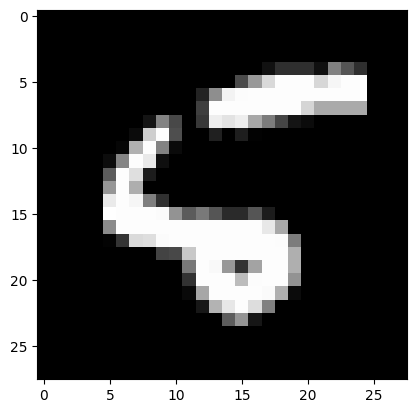

Label =  tensor(5)


In [7]:
# visualize the image
import matplotlib.pyplot as plt
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.show()
print("Label = ", all_test_labels[idx])

In [8]:
print(ensemble_lenet.predict(image.view(1, *image.shape))[0])

tensor([[1.7199e-14, 1.0718e-16, 2.3986e-19, 3.8625e-16, 3.1982e-13, 9.8879e-01,
         1.1078e-02, 1.6478e-17, 1.2773e-04, 6.9556e-10]],
       grad_fn=<CatBackward0>)


In [9]:
from property_procedures import validity_procedure


counter_factual, cf_steps = validity_procedure(
    ensemble_lenet,
    image.view(1, *image.shape),
    ensemble_probs,
    desired_class=6,
    MAX_STEPS=1000,
    DESIRED_VALIDITY=0.9999,
    total_uncertainty_ensemble=total_uncertainty_ensemble
)

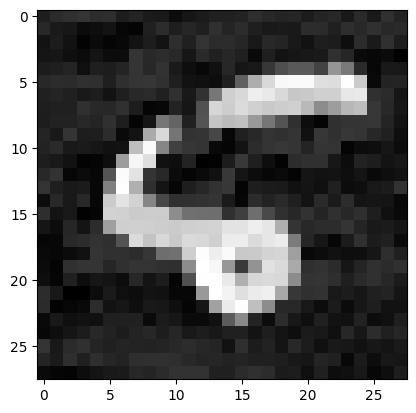

In [10]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


In [ ]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [11]:
probs = ensemble_probs(ensemble_lenet, counter_factual).mean(dim=1)
print(probs)

tensor([[9.6740e-07, 1.2597e-15, 5.6740e-17, 6.8079e-17, 3.6035e-09, 6.4933e-09,
         9.9990e-01, 6.5541e-20, 9.2695e-05, 2.4638e-06]],
       grad_fn=<MeanBackward1>)


In [12]:
ensemble_lenet.predict(counter_factual)

(tensor([[9.6740e-07, 1.2597e-15, 5.6740e-17, 6.8079e-17, 3.6035e-09, 6.4933e-09,
          9.9990e-01, 6.5541e-20, 9.2695e-05, 2.4638e-06]],
        grad_fn=<CatBackward0>),
 tensor([[6.7133e-05]], grad_fn=<CatBackward0>))

In [13]:
from property_procedures import plausability_procedure

counter_factual, cf_steps = plausability_procedure(
    ensemble_lenet,
    image.view(1, *image.shape),
    ensemble_probs,
    desired_class=6,
    MAX_STEPS=1000,
    DESIRED_VALIDITY=0.9999,
    epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
    lambda_1=1
)

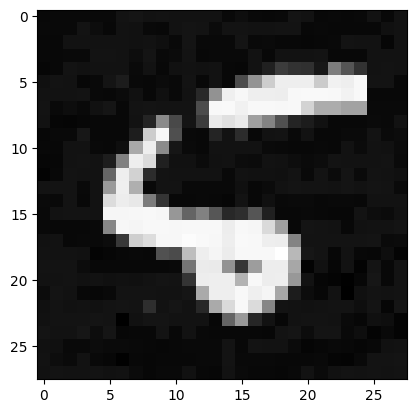

In [14]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


In [ ]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [15]:
from property_procedures import discriminiative_procedure

counter_factual, cf_steps = discriminiative_procedure(
    ensemble_lenet,
    image.view(1, *image.shape),
    ensemble_probs,
    desired_class=6,
    MAX_STEPS=1000,
    DESIRED_VALIDITY=0.9999,
    aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
    lambda_1=1
)

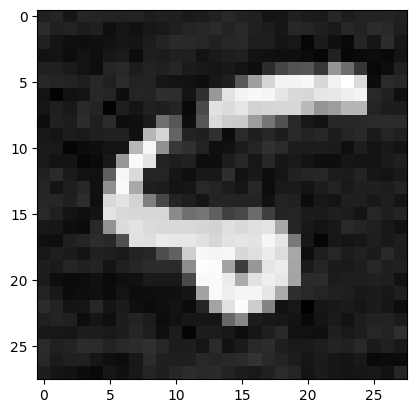

In [16]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


In [ ]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [68]:
from property_procedures import robust_procedure

counter_factual, cf_steps = robust_procedure(
    ensemble_lenet,
    image.view(1, *image.shape),
    ensemble_probs,
    desired_class=9,
    MAX_STEPS=1000,
    DESIRED_VALIDITY=0.9,
    aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
    epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
    delta=4,
    lambda_1=1,
    lambda_2=1
)

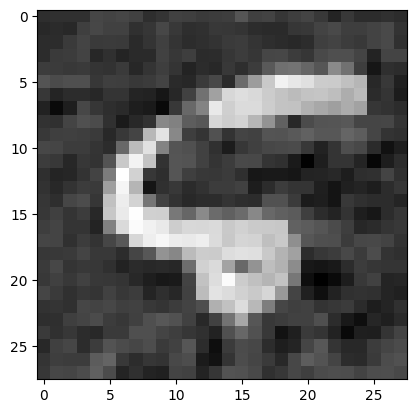

In [69]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


In [70]:
print(ensemble_lenet.predict(counter_factual)[0])

tensor([[6.5673e-08, 2.5001e-09, 2.3516e-11, 3.5439e-12, 8.6400e-03, 5.7413e-02,
         1.4028e-06, 2.3452e-10, 2.6661e-06, 9.3394e-01]],
       grad_fn=<CatBackward0>)


In [71]:
print(ensemble_lenet.predict(counter_factual,raw_output=True)[1])

tensor([[0.1168, 0.0664, 0.0504]], grad_fn=<CatBackward0>)


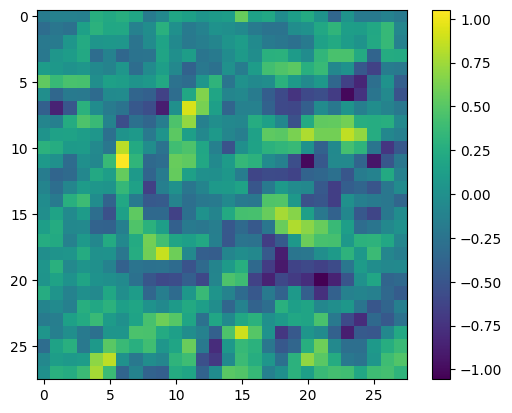

In [72]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()